In [3]:
!pip install yfinance ta scikit-learn xgboost joblib -q

import yfinance as yf
import pandas as pd
import numpy as np
import ta
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

  Preparing metadata (setup.py) ... done


In [4]:
def build_feature_dataframe(ticker: str, period: str = "2y") -> pd.DataFrame:
    """
    Fetches OHLCV data and computes all technical indicators.
    Returns a clean dataframe ready for ML feature engineering.
    """
    # fetch
    t = yf.Ticker(ticker)
    df = t.history(period=period)
    df = df.drop(columns=['Dividends', 'Stock Splits'])
    df.index = df.index.tz_localize(None)
    df = df.ffill()
    
    # indicators
    df['RSI'] = ta.momentum.RSIIndicator(close=df['Close'], window=14).rsi()
    
    macd = ta.trend.MACD(close=df['Close'], window_slow=26, window_fast=12, window_sign=9)
    df['MACD'] = macd.macd()
    df['MACD_signal'] = macd.macd_signal()
    df['MACD_histogram'] = macd.macd_diff()
    
    bb = ta.volatility.BollingerBands(close=df['Close'], window=20, window_dev=2)
    df['BB_upper'] = bb.bollinger_hband()
    df['BB_mid'] = bb.bollinger_mavg()
    df['BB_lower'] = bb.bollinger_lband()
    df['BB_width'] = bb.bollinger_wband()
    
    df['SMA_50'] = ta.trend.SMAIndicator(close=df['Close'], window=50).sma_indicator()
    df['SMA_200'] = ta.trend.SMAIndicator(close=df['Close'], window=200).sma_indicator()
    df['EMA_12'] = ta.trend.EMAIndicator(close=df['Close'], window=12).ema_indicator()
    df['EMA_26'] = ta.trend.EMAIndicator(close=df['Close'], window=26).ema_indicator()
    
    # drop NaN rows — only keep rows where all indicators are computed
    df = df.dropna()
    
    return df

# test
df = build_feature_dataframe("RELIANCE.NS")
print(df.shape)
print(df.columns.tolist())

(298, 17)
['Open', 'High', 'Low', 'Close', 'Volume', 'RSI', 'MACD', 'MACD_signal', 'MACD_histogram', 'BB_upper', 'BB_mid', 'BB_lower', 'BB_width', 'SMA_50', 'SMA_200', 'EMA_12', 'EMA_26']


In [5]:
# CREATE TARGET VARIABLE
# For each day, look 5 trading days into the future
# Calculate % price change over those 5 days
# Label it UP / DOWN / NEUTRAL

FUTURE_DAYS = 5
THRESHOLD = 0.02  # 2%

# shift(-5) means "the Close price 5 days from now"
df['Future_Close'] = df['Close'].shift(-FUTURE_DAYS)
df['Future_Return'] = (df['Future_Close'] - df['Close']) / df['Close']

def label(ret):
    if ret > THRESHOLD:
        return 'UP'
    elif ret < -THRESHOLD:
        return 'DOWN'
    else:
        return 'NEUTRAL'

df['Target'] = df['Future_Return'].apply(label)

# drop the last 5 rows — they have no future data
df = df.dropna(subset=['Future_Close'])

# check class distribution
print("Target distribution:")
print(df['Target'].value_counts())
print(f"\nTotal rows: {len(df)}")
print(f"\nSample — last 10 rows:")
print(df[['Close', 'Future_Close', 'Future_Return', 'Target']].tail(10))

Target distribution:
Target
NEUTRAL    156
UP          73
DOWN        64
Name: count, dtype: int64

Total rows: 293

Sample — last 10 rows:
                  Close  Future_Close  Future_Return   Target
Date                                                         
2026-05-06  1437.900024   1358.800049      -0.055011     DOWN
2026-05-07  1436.199951   1361.800049      -0.051803     DOWN
2026-05-08  1435.199951   1336.400024      -0.068841     DOWN
2026-05-11  1388.199951   1335.900024      -0.037675     DOWN
2026-05-12  1364.000000   1322.699951      -0.030279     DOWN
2026-05-13  1358.800049   1359.699951       0.000662  NEUTRAL
2026-05-14  1361.800049   1349.599976      -0.008959  NEUTRAL
2026-05-15  1336.400024   1354.500000       0.013544  NEUTRAL
2026-05-18  1335.900024   1367.000000       0.023280       UP
2026-05-19  1322.699951   1356.300049       0.025403       UP


In [6]:
# FEATURE ENGINEERING
# Create derived features that capture momentum and relative position

# 1. Price position relative to moving averages
# "How far is price from its SMA?" is more useful than raw price
df['Price_vs_SMA50'] = (df['Close'] - df['SMA_50']) / df['SMA_50']
df['Price_vs_SMA200'] = (df['Close'] - df['SMA_200']) / df['SMA_200']
df['Price_vs_BB_mid'] = (df['Close'] - df['BB_mid']) / df['BB_mid']

# 2. Price position within Bollinger Bands
# 0 = at lower band, 1 = at upper band, 0.5 = at middle
df['BB_position'] = (df['Close'] - df['BB_lower']) / (df['BB_upper'] - df['BB_lower'])

# 3. Momentum — how much has price moved recently
df['Return_1d'] = df['Close'].pct_change(1)   # yesterday's return
df['Return_5d'] = df['Close'].pct_change(5)   # last 5 days return
df['Return_10d'] = df['Close'].pct_change(10) # last 10 days return

# 4. RSI momentum — is RSI rising or falling?
df['RSI_change'] = df['RSI'].diff(3)  # RSI change over last 3 days

# 5. MACD momentum — is histogram growing or shrinking?
df['MACD_hist_change'] = df['MACD_histogram'].diff(3)

# 6. Volume momentum — is volume increasing?
df['Volume_SMA20'] = df['Volume'].rolling(20).mean()
df['Volume_ratio'] = df['Volume'] / df['Volume_SMA20']  # >1 = above average volume

# drop any NaN created by these new features
df = df.dropna()

print(f"Shape after feature engineering: {df.shape}")
print(f"\nNew features added:")
new_features = ['Price_vs_SMA50', 'Price_vs_SMA200', 'Price_vs_BB_mid', 
                'BB_position', 'Return_1d', 'Return_5d', 'Return_10d',
                'RSI_change', 'MACD_hist_change', 'Volume_ratio']
print(df[new_features].tail(5).round(4))

Shape after feature engineering: (274, 31)

New features added:
            Price_vs_SMA50  Price_vs_SMA200  Price_vs_BB_mid  BB_position  \
Date                                                                        
2026-05-13         -0.0165          -0.0509          -0.0241       0.3013   
2026-05-14         -0.0137          -0.0487          -0.0226       0.3096   
2026-05-15         -0.0313          -0.0662          -0.0398       0.1757   
2026-05-18         -0.0314          -0.0663          -0.0392       0.1903   
2026-05-19         -0.0406          -0.0753          -0.0477       0.1385   

            Return_1d  Return_5d  Return_10d  RSI_change  MACD_hist_change  \
Date                                                                         
2026-05-13    -0.0038    -0.0550     -0.0467    -16.3267          -13.1920   
2026-05-14     0.0022    -0.0518     -0.0482     -4.6565          -10.1634   
2026-05-15    -0.0187    -0.0688     -0.0660     -4.7609           -7.7805   
2026-0

In [7]:
# DEFINE FEATURES AND TARGET
FEATURES = [
    'RSI', 'MACD', 'MACD_signal', 'MACD_histogram',
    'BB_width', 'BB_position',
    'SMA_50', 'SMA_200', 'EMA_12', 'EMA_26',
    'Price_vs_SMA50', 'Price_vs_SMA200', 'Price_vs_BB_mid',
    'Return_1d', 'Return_5d', 'Return_10d',
    'RSI_change', 'MACD_hist_change', 'Volume_ratio'
]

X = df[FEATURES]
y = df['Target']

# TEMPORAL SPLIT — critical, never use random split for financial data
# Reason: if you randomly split, your training data contains future dates
# and your test data contains past dates — model has "seen the future"
# This inflates accuracy artificially — called data leakage
# Correct approach: first 80% of dates = train, last 20% = test, strictly in order

split_idx = int(len(df) * 0.8)
split_date = df.index[split_idx]

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"Split date: {split_date.date()}")
print(f"Training: {len(X_train)} rows ({X_train.index[0].date()} to {X_train.index[-1].date()})")
print(f"Testing:  {len(X_test)} rows ({X_test.index[0].date()} to {X_test.index[-1].date()})")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")

Split date: 2026-02-25
Training: 219 rows (2025-04-09 to 2026-02-24)
Testing:  55 rows (2026-02-25 to 2026-05-19)

Train class distribution:
Target
NEUTRAL    127
UP          51
DOWN        41
Name: count, dtype: int64

Test class distribution:
Target
NEUTRAL    24
DOWN       16
UP         15
Name: count, dtype: int64


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        DOWN       0.80      0.25      0.38        16
     NEUTRAL       0.50      0.33      0.40        24
          UP       0.29      0.67      0.41        15

    accuracy                           0.40        55
   macro avg       0.53      0.42      0.40        55
weighted avg       0.53      0.40      0.40        55

CONFUSION MATRIX


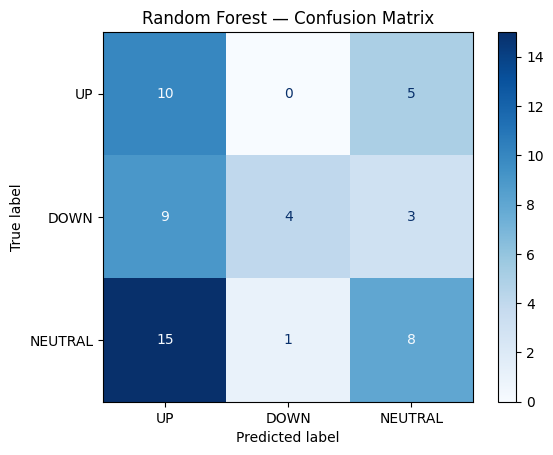

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# TRAIN RANDOM FOREST
rf_model = RandomForestClassifier(
    n_estimators=200,      # 200 trees — more trees = more stable, diminishing returns after 200
    max_depth=6,           # prevents overfitting — trees can't go too deep
    min_samples_leaf=5,    # each leaf needs at least 5 samples — prevents memorizing noise
    class_weight='balanced', # compensates for NEUTRAL dominating — treats all classes equally
    random_state=42        # reproducibility — same result every run
)

rf_model.fit(X_train, y_train)

# EVALUATE
y_pred = rf_model.predict(X_test)

print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred))

print("=" * 50)
print("CONFUSION MATRIX")
print("=" * 50)
cm = confusion_matrix(y_test, y_pred, labels=['UP', 'DOWN', 'NEUTRAL'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['UP', 'DOWN', 'NEUTRAL'])
disp.plot(cmap='Blues')
plt.title('Random Forest — Confusion Matrix')
plt.show()

In [9]:
# FIX 1: Get more data — use 5 years instead of 2
df5 = build_feature_dataframe("RELIANCE.NS", period="5y")

# add all the same features
df5['Price_vs_SMA50'] = (df5['Close'] - df5['SMA_50']) / df5['SMA_50']
df5['Price_vs_SMA200'] = (df5['Close'] - df5['SMA_200']) / df5['SMA_200']
df5['Price_vs_BB_mid'] = (df5['Close'] - df5['BB_mid']) / df5['BB_mid']
df5['BB_position'] = (df5['Close'] - df5['BB_lower']) / (df5['BB_upper'] - df5['BB_lower'])
df5['Return_1d'] = df5['Close'].pct_change(1)
df5['Return_5d'] = df5['Close'].pct_change(5)
df5['Return_10d'] = df5['Close'].pct_change(10)
df5['RSI_change'] = df5['RSI'].diff(3)
df5['MACD_hist_change'] = df5['MACD_histogram'].diff(3)
df5['Volume_SMA20'] = df5['Volume'].rolling(20).mean()
df5['Volume_ratio'] = df5['Volume'] / df5['Volume_SMA20']

# create target
df5['Future_Close'] = df5['Close'].shift(-5)
df5['Future_Return'] = (df5['Future_Close'] - df5['Close']) / df5['Close']
df5['Target'] = df5['Future_Return'].apply(label)
df5 = df5.dropna()

print(f"5-year dataset shape: {df5.shape}")
print(f"Target distribution:\n{df5['Target'].value_counts()}")

5-year dataset shape: (1015, 31)
Target distribution:
Target
NEUTRAL    526
UP         255
DOWN       234
Name: count, dtype: int64


Training: 812 rows (2022-04-08 to 2025-07-22)
Testing:  203 rows (2025-07-23 to 2026-05-19)

CLASSIFICATION REPORT — 5 year data
              precision    recall  f1-score   support

        DOWN       0.24      0.56      0.33        43
     NEUTRAL       0.51      0.32      0.40       117
          UP       0.29      0.19      0.23        43

    accuracy                           0.34       203
   macro avg       0.35      0.36      0.32       203
weighted avg       0.41      0.34      0.35       203



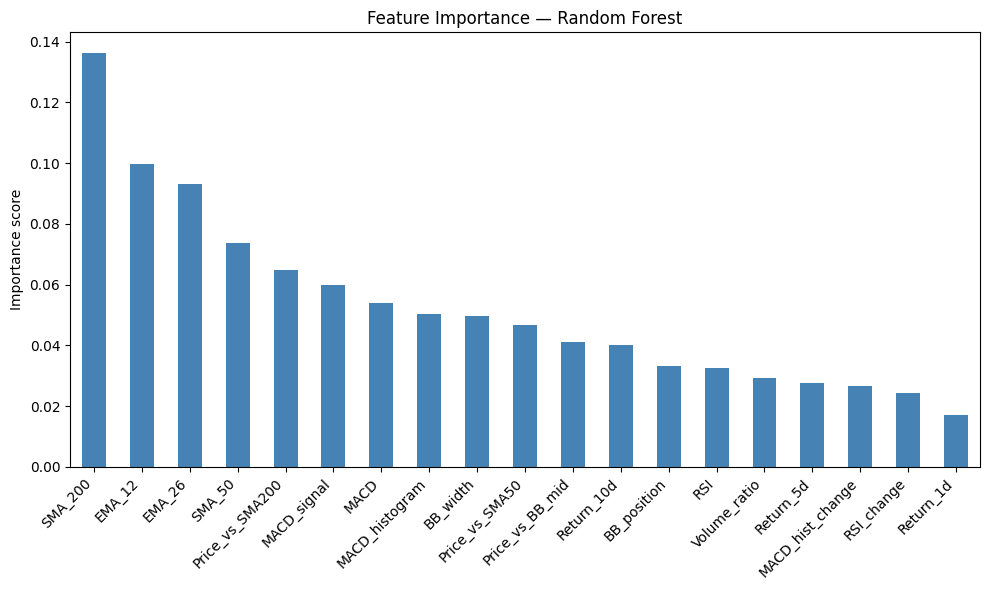


Top 5 most important features:
SMA_200            0.136233
EMA_12             0.099701
EMA_26             0.093091
SMA_50             0.073844
Price_vs_SMA200    0.064698
dtype: float64


In [10]:
# retrain with 5 year data
X5 = df5[FEATURES]
y5 = df5['Target']

# temporal split — same logic, strictly in order
split_idx5 = int(len(df5) * 0.8)

X5_train = X5.iloc[:split_idx5]
X5_test = X5.iloc[split_idx5:]
y5_train = y5.iloc[:split_idx5]
y5_test = y5.iloc[split_idx5:]

print(f"Training: {len(X5_train)} rows ({X5_train.index[0].date()} to {X5_train.index[-1].date()})")
print(f"Testing:  {len(X5_test)} rows ({X5_test.index[0].date()} to {X5_test.index[-1].date()})")

# train
rf_model5 = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

rf_model5.fit(X5_train, y5_train)
y5_pred = rf_model5.predict(X5_test)

print("\n" + "=" * 50)
print("CLASSIFICATION REPORT — 5 year data")
print("=" * 50)
print(classification_report(y5_test, y5_pred))

# feature importance — what did the model find most useful?
importances = pd.Series(rf_model5.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.ylabel('Importance score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importances.head())

In [11]:
# SIMPLIFIED: binary classification — UP vs DOWN only
# drop NEUTRAL rows — only keep decisive moves
df_binary = df5[df5['Target'] != 'NEUTRAL'].copy()
df_binary['Target_binary'] = (df_binary['Target'] == 'UP').astype(int)
# 1 = UP, 0 = DOWN

print(f"Binary dataset shape: {df_binary.shape}")
print(f"Class distribution:\n{df_binary['Target_binary'].value_counts()}")
print(f"UP: {(df_binary['Target_binary']==1).sum()}, DOWN: {(df_binary['Target_binary']==0).sum()}")

Binary dataset shape: (489, 32)
Class distribution:
Target_binary
1    255
0    234
Name: count, dtype: int64
UP: 255, DOWN: 234


In [12]:
# use only last 2 years of data for binary model
cutoff = df_binary.index[-1] - pd.DateOffset(years=2)
df_recent = df_binary[df_binary.index >= cutoff]

print(f"\nRecent 2-year binary dataset: {df_recent.shape}")
print(f"Date range: {df_recent.index[0].date()} to {df_recent.index[-1].date()}")


Recent 2-year binary dataset: (236, 32)
Date range: 2024-05-23 to 2026-05-19


Training: 188 rows (2024-05-23 to 2026-01-07)
Testing:  48 rows (2026-01-12 to 2026-05-19)

BINARY CLASSIFICATION REPORT
              precision    recall  f1-score   support

        DOWN       0.58      1.00      0.74        28
          UP       0.00      0.00      0.00        20

    accuracy                           0.58        48
   macro avg       0.29      0.50      0.37        48
weighted avg       0.34      0.58      0.43        48



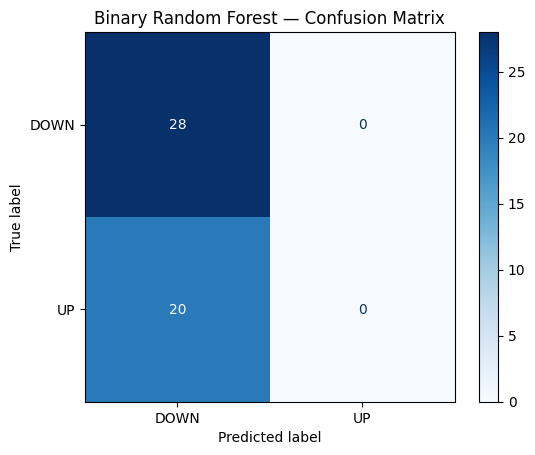

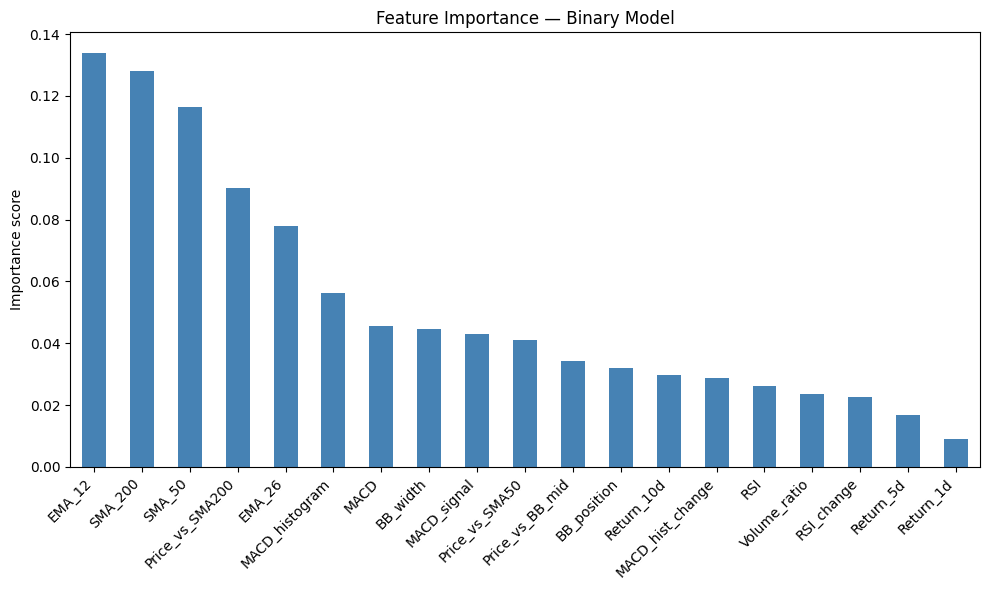


Top 5 features:
EMA_12             0.133900
SMA_200            0.127945
SMA_50             0.116520
Price_vs_SMA200    0.090244
EMA_26             0.077981
dtype: float64


In [13]:
# BINARY MODEL — UP vs DOWN only, recent 2 years
X_bin = df_recent[FEATURES]
y_bin = df_recent['Target_binary']

# temporal split
split_idx_bin = int(len(df_recent) * 0.8)

X_bin_train = X_bin.iloc[:split_idx_bin]
X_bin_test = X_bin.iloc[split_idx_bin:]
y_bin_train = y_bin.iloc[:split_idx_bin]
y_bin_test = y_bin.iloc[split_idx_bin:]

print(f"Training: {len(X_bin_train)} rows ({X_bin_train.index[0].date()} to {X_bin_train.index[-1].date()})")
print(f"Testing:  {len(X_bin_test)} rows ({X_bin_test.index[0].date()} to {X_bin_test.index[-1].date()})")

# train
rf_binary = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,          # slightly shallower — less overfitting on smaller dataset
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42
)

rf_binary.fit(X_bin_train, y_bin_train)
y_bin_pred = rf_binary.predict(X_bin_test)
y_bin_proba = rf_binary.predict_proba(X_bin_test)  # confidence scores

print("\n" + "=" * 50)
print("BINARY CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_bin_test, y_bin_pred, target_names=['DOWN', 'UP']))

# confusion matrix
cm = confusion_matrix(y_bin_test, y_bin_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['DOWN', 'UP'])
disp.plot(cmap='Blues')
plt.title('Binary Random Forest — Confusion Matrix')
plt.show()

# feature importance
importances = pd.Series(rf_binary.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='steelblue')
plt.title('Feature Importance — Binary Model')
plt.ylabel('Importance score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
print(importances.head())

In [14]:
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# XGBoost — better than Random Forest on small tabular datasets
# handles class imbalance natively with scale_pos_weight

n_down = (y_bin_train == 0).sum()
n_up = (y_bin_train == 1).sum()
scale = n_down / n_up  # weight UP examples more since they're fewer

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,           # shallow — critical for small datasets
    learning_rate=0.05,    # slow learning = less overfitting
    subsample=0.8,         # use 80% of rows per tree — reduces overfitting
    colsample_bytree=0.8,  # use 80% of features per tree
    scale_pos_weight=scale,# compensates for class imbalance
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

# TimeSeriesSplit — cross validation that respects time order
# splits data into 5 folds, always training on past, testing on future
tscv = TimeSeriesSplit(n_splits=5)

cv_scores = cross_val_score(
    xgb_model, X_bin, y_bin,
    cv=tscv,
    scoring='f1_macro'
)

print("Time Series Cross Validation F1 scores:")
for i, score in enumerate(cv_scores):
    print(f"  Fold {i+1}: {score:.3f}")
print(f"  Mean: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

# train final model on train split, evaluate on test
xgb_model.fit(X_bin_train, y_bin_train)
y_xgb_pred = xgb_model.predict(X_bin_test)
y_xgb_proba = xgb_model.predict_proba(X_bin_test)

print("\n" + "="*50)
print("XGBoost CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_bin_test, y_xgb_pred, target_names=['DOWN', 'UP']))

Time Series Cross Validation F1 scores:
  Fold 1: 0.331
  Fold 2: 0.606
  Fold 3: 0.422
  Fold 4: 0.652
  Fold 5: 0.478
  Mean: 0.498 (+/- 0.118)

XGBoost CLASSIFICATION REPORT
              precision    recall  f1-score   support

        DOWN       0.58      1.00      0.74        28
          UP       0.00      0.00      0.00        20

    accuracy                           0.58        48
   macro avg       0.29      0.50      0.37        48
weighted avg       0.34      0.58      0.43        48



In [15]:
# THE REAL FIX — adjust threshold and prediction window
# Problem: 2% threshold over 5 days creates too many DOWN labels
# in a bearish period, making UP nearly unpredictable
# Solution: use 1% threshold and 3-day window — more balanced labels

def create_target(df, future_days=3, threshold=0.01):
    df = df.copy()
    df['Future_Close'] = df['Close'].shift(-future_days)
    df['Future_Return'] = (df['Future_Close'] - df['Close']) / df['Close']
    
    def label(ret):
        if ret > threshold:
            return 1  # UP
        else:
            return 0  # DOWN
    
    df['Target_binary'] = df['Future_Return'].apply(label)
    df = df.dropna(subset=['Future_Close'])
    return df

# rebuild on full 5y data with new threshold
df5_new = build_feature_dataframe("RELIANCE.NS", period="5y")

# add features
df5_new['Price_vs_SMA50'] = (df5_new['Close'] - df5_new['SMA_50']) / df5_new['SMA_50']
df5_new['Price_vs_SMA200'] = (df5_new['Close'] - df5_new['SMA_200']) / df5_new['SMA_200']
df5_new['Price_vs_BB_mid'] = (df5_new['Close'] - df5_new['BB_mid']) / df5_new['BB_mid']
df5_new['BB_position'] = (df5_new['Close'] - df5_new['BB_lower']) / (df5_new['BB_upper'] - df5_new['BB_lower'])
df5_new['Return_1d'] = df5_new['Close'].pct_change(1)
df5_new['Return_5d'] = df5_new['Close'].pct_change(5)
df5_new['Return_10d'] = df5_new['Close'].pct_change(10)
df5_new['RSI_change'] = df5_new['RSI'].diff(3)
df5_new['MACD_hist_change'] = df5_new['MACD_histogram'].diff(3)
df5_new['Volume_SMA20'] = df5_new['Volume'].rolling(20).mean()
df5_new['Volume_ratio'] = df5_new['Volume'] / df5_new['Volume_SMA20']
df5_new = df5_new.dropna()

# apply new target
df5_new = create_target(df5_new, future_days=3, threshold=0.01)

print(f"Shape: {df5_new.shape}")
print(f"Class distribution:\n{df5_new['Target_binary'].value_counts()}")
print(f"Balance ratio: {df5_new['Target_binary'].mean():.2f} (0.5 = perfect)")

Shape: (1017, 31)
Class distribution:
Target_binary
0    687
1    330
Name: count, dtype: int64
Balance ratio: 0.32 (0.5 = perfect)


In [16]:
from sklearn.utils import resample

# HANDLE IMBALANCE PROPERLY — undersample majority class
# keep all UP rows, randomly sample equal number of DOWN rows
# do this only on training data, never on test data

X5_new = df5_new[FEATURES]
y5_new = df5_new['Target_binary']

# temporal split first
split_idx = int(len(df5_new) * 0.8)
X_tr = X5_new.iloc[:split_idx]
X_te = X5_new.iloc[split_idx:]
y_tr = y5_new.iloc[:split_idx]
y_te = y5_new.iloc[split_idx:]

print(f"Train: {len(X_tr)} rows | Test: {len(X_te)} rows")
print(f"Train distribution:\n{y_tr.value_counts()}")
print(f"Test distribution:\n{y_te.value_counts()}")

# undersample training data only
train_df = pd.concat([X_tr, y_tr], axis=1)
down_rows = train_df[train_df['Target_binary'] == 0]
up_rows = train_df[train_df['Target_binary'] == 1]

# downsample DOWN to match UP count
down_downsampled = resample(down_rows, 
                            n_samples=len(up_rows), 
                            random_state=42)

train_balanced = pd.concat([up_rows, down_downsampled])
train_balanced = train_balanced.sample(frac=1, random_state=42)  # shuffle

X_tr_bal = train_balanced[FEATURES]
y_tr_bal = train_balanced['Target_binary']

print(f"\nBalanced training set: {len(X_tr_bal)} rows")
print(f"Distribution:\n{y_tr_bal.value_counts()}")

Train: 813 rows | Test: 204 rows
Train distribution:
Target_binary
0    550
1    263
Name: count, dtype: int64
Test distribution:
Target_binary
0    137
1     67
Name: count, dtype: int64

Balanced training set: 526 rows
Distribution:
Target_binary
0    263
1    263
Name: count, dtype: int64


FINAL MODEL — CLASSIFICATION REPORT
              precision    recall  f1-score   support

        DOWN       0.58      0.38      0.46       137
          UP       0.26      0.45      0.33        67

    accuracy                           0.40       204
   macro avg       0.42      0.41      0.39       204
weighted avg       0.48      0.40      0.42       204



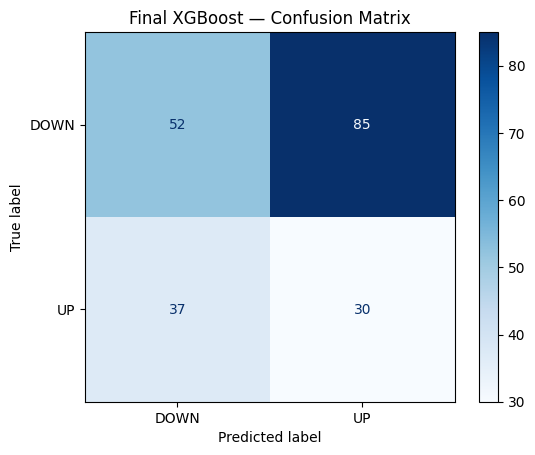

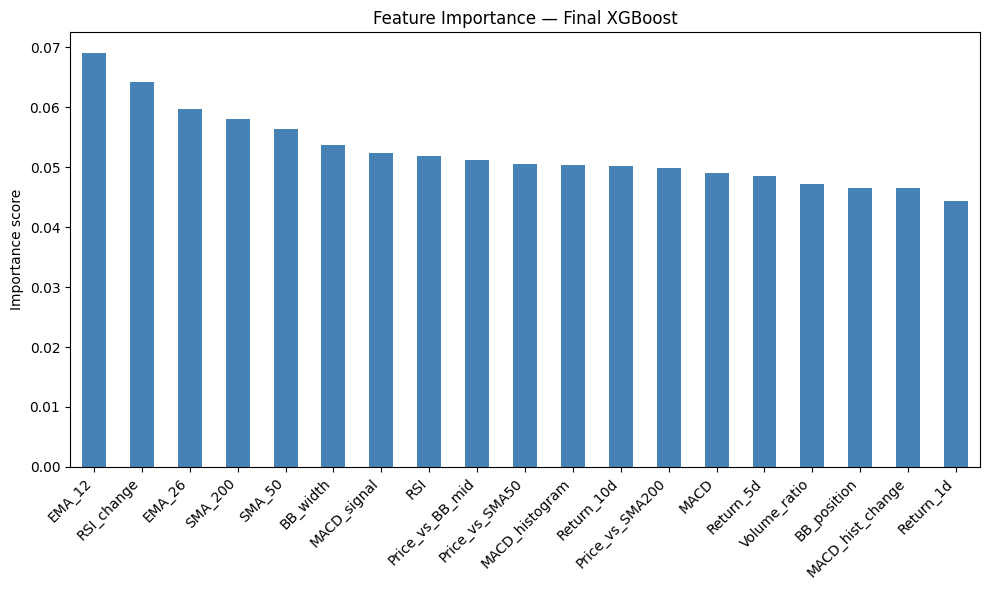

Top 5 features:
EMA_12        0.069074
RSI_change    0.064222
EMA_26        0.059782
SMA_200       0.058142
SMA_50        0.056333
dtype: float32


In [17]:
# FINAL MODEL — XGBoost on balanced training data
xgb_final = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_final.fit(X_tr_bal, y_tr_bal)
y_final_pred = xgb_final.predict(X_te)
y_final_proba = xgb_final.predict_proba(X_te)

print("="*50)
print("FINAL MODEL — CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_te, y_final_pred, target_names=['DOWN', 'UP']))

# confusion matrix
cm = confusion_matrix(y_te, y_final_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['DOWN', 'UP'])
disp.plot(cmap='Blues')
plt.title('Final XGBoost — Confusion Matrix')
plt.show()

# feature importance
importances = pd.Series(xgb_final.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='steelblue')
plt.title('Feature Importance — Final XGBoost')
plt.ylabel('Importance score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 5 features:")
print(importances.head())

In [18]:
def predict_signal(ticker: str) -> dict:
    """
    Given a ticker, returns UP/DOWN signal with confidence score.
    This is what the FastAPI /stock/{ticker}/signal endpoint will call.
    """
    # build features for this ticker
    df_pred = build_feature_dataframe(ticker, period="5y")
    
    # add all features
    df_pred['Price_vs_SMA50'] = (df_pred['Close'] - df_pred['SMA_50']) / df_pred['SMA_50']
    df_pred['Price_vs_SMA200'] = (df_pred['Close'] - df_pred['SMA_200']) / df_pred['SMA_200']
    df_pred['Price_vs_BB_mid'] = (df_pred['Close'] - df_pred['BB_mid']) / df_pred['BB_mid']
    df_pred['BB_position'] = (df_pred['Close'] - df_pred['BB_lower']) / (df_pred['BB_upper'] - df_pred['BB_lower'])
    df_pred['Return_1d'] = df_pred['Close'].pct_change(1)
    df_pred['Return_5d'] = df_pred['Close'].pct_change(5)
    df_pred['Return_10d'] = df_pred['Close'].pct_change(10)
    df_pred['RSI_change'] = df_pred['RSI'].diff(3)
    df_pred['MACD_hist_change'] = df_pred['MACD_histogram'].diff(3)
    df_pred['Volume_SMA20'] = df_pred['Volume'].rolling(20).mean()
    df_pred['Volume_ratio'] = df_pred['Volume'] / df_pred['Volume_SMA20']
    df_pred = df_pred.dropna()
    
    # get the latest row — today's features
    latest = df_pred[FEATURES].iloc[[-1]]
    
    # predict
    proba = xgb_final.predict_proba(latest)[0]
    pred = xgb_final.predict(latest)[0]
    
    signal = "UP" if pred == 1 else "DOWN"
    confidence = float(proba[pred])
    
    # feature importances for explainability
    top_features = importances.head(3).index.tolist()
    
    return {
        "ticker": ticker,
        "signal": signal,
        "confidence": round(confidence, 3),
        "top_features": top_features,
        "disclaimer": "ML signal only — not financial advice"
    }

# test it
result = predict_signal("RELIANCE.NS")
print(result)

result_tcs = predict_signal("TCS.NS")
print(result_tcs)

{'ticker': 'RELIANCE.NS', 'signal': 'DOWN', 'confidence': 0.534, 'top_features': ['EMA_12', 'RSI_change', 'EMA_26'], 'disclaimer': 'ML signal only — not financial advice'}
{'ticker': 'TCS.NS', 'signal': 'UP', 'confidence': 0.554, 'top_features': ['EMA_12', 'RSI_change', 'EMA_26'], 'disclaimer': 'ML signal only — not financial advice'}


In [19]:
import joblib
import os

# create ml folder if it doesn't exist
os.makedirs('ml', exist_ok=True)

# save the trained model
joblib.dump(xgb_final, 'ml/price_model.pkl')

# save the feature list — backend needs to know exact feature order
joblib.dump(FEATURES, 'ml/features.pkl')

# verify it saved and can be loaded back
loaded_model = joblib.load('ml/price_model.pkl')
loaded_features = joblib.load('ml/features.pkl')

# test loaded model gives same result
test_result = predict_signal("RELIANCE.NS")
print("Model saved and verified.")
print(f"Signal: {test_result['signal']}, Confidence: {test_result['confidence']}")
print(f"Features list saved: {len(loaded_features)} features")

Model saved and verified.
Signal: DOWN, Confidence: 0.534
Features list saved: 19 features


In [20]:
!pip install feedparser -q

from transformers import pipeline
import feedparser

print("Loading FinBERT...")
finbert = pipeline(
    "text-classification", 
    model="ProsusAI/finbert",
    return_all_scores=True
)
print("FinBERT loaded.")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 2.0 MB/s eta 0:00:00a 0:00:01
Loading FinBERT...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

FinBERT loaded.


In [22]:
BLOCKED_SOURCES = ["facebook.com", "twitter.com", "instagram.com", "reddit.com"]

def fetch_headlines(company_name: str) -> list:
    try:
        query = company_name.replace(" ", "+")
        url = f"https://news.google.com/rss/search?q={query}&hl=en-IN&gl=IN&ceid=IN:en"
        feed = feedparser.parse(url)
        if not feed.entries:
            return []
        headlines = [
            {
                "title": entry.title,
                "published_at": entry.published,
                "source": entry.source.get("title", "Google News") if hasattr(entry, "source") else "Google News"
            }
            for entry in feed.entries[:15]
            if not any(
                blocked in (entry.source.get("title", "") if hasattr(entry, "source") else "").lower()
                for blocked in BLOCKED_SOURCES
            )
        ]
        return headlines
    except Exception as e:
        print(f"Error: {e}")
        return []

In [23]:
def analyze_sentiment(company_name: str) -> dict:
    headlines = fetch_headlines(company_name)
    
    if not headlines:
        return {"error": "No headlines found", "headlines": [], "aggregate": None}
    
    results = []
    for h in headlines:
        # FinBERT returns list with single dict: [{'label': 'positive', 'score': 0.75}]
        output = finbert(h['title'])[0]  # get the single result dict
        
        dominant = output['label']       # 'positive', 'negative', or 'neutral'
        confidence = output['score']
        
        results.append({
            "title": h['title'],
            "source": h['source'],
            "published_at": h['published_at'],
            "sentiment": dominant,
            "confidence": round(confidence, 3)
        })
    
    # aggregate score
    sentiment_map = {"positive": 1, "negative": -1, "neutral": 0}
    aggregate = sum(
        sentiment_map[r['sentiment']] * r['confidence']
        for r in results
    ) / len(results)
    
    if aggregate > 0.1:
        overall = "BULLISH"
    elif aggregate < -0.1:
        overall = "BEARISH"
    else:
        overall = "NEUTRAL"
    
    return {
        "company": company_name,
        "headlines_analyzed": len(results),
        "aggregate_score": round(aggregate, 3),
        "overall_sentiment": overall,
        "headlines": results
    }

# test
result = analyze_sentiment("Reliance Industries")
print(f"Company: {result['company']}")
print(f"Headlines analyzed: {result['headlines_analyzed']}")
print(f"Aggregate score: {result['aggregate_score']}")
print(f"Overall sentiment: {result['overall_sentiment']}")
print(f"\nHeadline breakdown:")
for h in result['headlines']:
    print(f"  [{h['sentiment'].upper()} {h['confidence']}] {h['title'][:70]}...")

Company: Reliance Industries
Headlines analyzed: 13
Aggregate score: 0.178
Overall sentiment: BULLISH

Headline breakdown:
  [NEGATIVE 0.705] 'n-Hexane' Not 'Motor Spirt' For Customs Duty : Supreme Court Dismisse...
  [POSITIVE 0.88] Reliance Industries becomes first Indian company to surpass $120 bln r...
  [POSITIVE 0.768] Reliance Industries Ltd Sees High-Value Trading Amid Mixed Market Sign...
  [NEUTRAL 0.897] Reliance Industries' n-Hexane Import Cannot Be Classified As Motor Spi...
  [NEUTRAL 0.808] Reliance Natural Gas Sale Classified as Inter‑State Transaction:Suprem...
  [POSITIVE 0.863] Market recap: 6 of top-10 most-valued firms add Rs 74,111 crore; Relia...
  [NEUTRAL 0.911] ‘Come Out With A Settlement, We Will Dispose Appeal’: Supreme Court To...
  [POSITIVE 0.722] SC agrees to Reliance plea for conciliation with Centre in KG basin di...
  [NEUTRAL 0.488] Reliance bribery probe: Executive gets bail after company hands over d...
  [NEUTRAL 0.95] Buy, Sell Or Hold: DLF, Ired

In [26]:
def momentum_breakout_signal(df: pd.DataFrame) -> dict:
    """
    UP if price breaks above 20-day high on above-average volume.
    Logic: breakout of recent range with volume confirmation = 
    momentum likely to continue in that direction.
    """
    if len(df) < 21:
        return {"signal": "INSUFFICIENT_DATA", "confidence": 0.0, "reason": "Need at least 21 days"}
    
    # use yesterday's 20d high as the breakout level
    # not today's — avoids look-ahead bias
    recent_high = df['High'].rolling(20).max().iloc[-2]
    recent_low = df['Low'].rolling(20).min().iloc[-2]
    current_price = df['Close'].iloc[-1]
    volume_ratio = df['Volume'].iloc[-1] / df['Volume'].rolling(20).mean().iloc[-1]
    
    if current_price > recent_high and volume_ratio > 1.5:
        signal = "UP"
        confidence = float(min(0.5 + (volume_ratio - 1.5) * 0.1, 0.85))
        reason = f"Price {current_price:.0f} broke above 20d high {recent_high:.0f} with {volume_ratio:.1f}x volume"
    elif current_price < recent_low and volume_ratio > 1.5:
        signal = "DOWN"
        confidence = float(min(0.5 + (volume_ratio - 1.5) * 0.1, 0.85))
        reason = f"Price {current_price:.0f} broke below 20d low {recent_low:.0f} with {volume_ratio:.1f}x volume"
    else:
        signal = "NEUTRAL"
        confidence = 0.5
        reason = f"No breakout — price between {recent_low:.0f} and {recent_high:.0f}, volume ratio {volume_ratio:.2f}x"
    
    return {
        "signal": signal,
        "confidence": float(round(confidence, 3)),
        "reason": reason,
        "strategy": "Momentum Breakout"
    }

# test
df_test = build_feature_dataframe("RELIANCE.NS")
result = momentum_breakout_signal(df_test)
print("Momentum Breakout:")
print(result)

Momentum Breakout:
{'signal': 'NEUTRAL', 'confidence': 0.5, 'reason': 'No breakout — price between 1313 and 1473, volume ratio 0.82x', 'strategy': 'Momentum Breakout'}


In [27]:
def mean_reversion_signal(df: pd.DataFrame) -> dict:
    """
    UP if RSI oversold + price near lower Bollinger Band.
    DOWN if RSI overbought + price near upper Bollinger Band.
    Logic: when a stock moves too far too fast, it statistically
    tends to revert toward its mean (average price).
    """
    if len(df) < 21:
        return {"signal": "INSUFFICIENT_DATA", "confidence": 0.0, "reason": "Need at least 21 days"}
    
    rsi = df['RSI'].iloc[-1]
    bb_position = (df['Close'].iloc[-1] - df['BB_lower'].iloc[-1]) / \
                  (df['BB_upper'].iloc[-1] - df['BB_lower'].iloc[-1])
    current_price = df['Close'].iloc[-1]
    
    # both conditions must be true — RSI AND bb_position
    # one signal alone is not enough, we need confirmation
    if rsi < 35 and bb_position < 0.25:
        signal = "UP"
        # stronger signal when RSI is lower and price is closer to lower band
        confidence = float(round(0.5 + (35 - rsi) / 100 + (0.25 - bb_position) / 2, 3))
        confidence = float(min(confidence, 0.85))
        reason = f"Oversold — RSI {rsi:.1f} (<35) and price at {bb_position:.0%} of BB range (near lower band)"
    
    elif rsi > 65 and bb_position > 0.75:
        signal = "DOWN"
        confidence = float(round(0.5 + (rsi - 65) / 100 + (bb_position - 0.75) / 2, 3))
        confidence = float(min(confidence, 0.85))
        reason = f"Overbought — RSI {rsi:.1f} (>65) and price at {bb_position:.0%} of BB range (near upper band)"
    
    else:
        signal = "NEUTRAL"
        confidence = 0.5
        reason = f"No extreme — RSI {rsi:.1f}, price at {bb_position:.0%} of BB range"
    
    return {
        "signal": signal,
        "confidence": float(round(confidence, 3)),
        "reason": reason,
        "strategy": "Mean Reversion"
    }

# test
result = mean_reversion_signal(df_test)
print("Mean Reversion:")
print(result)

Mean Reversion:
{'signal': 'NEUTRAL', 'confidence': 0.5, 'reason': 'No extreme — RSI 46.1, price at 32% of BB range', 'strategy': 'Mean Reversion'}


In [28]:
def macd_crossover_signal(df: pd.DataFrame) -> dict:
    """
    UP if MACD line just crossed above signal line.
    DOWN if MACD line just crossed below signal line.
    Logic: crossover = momentum shift — fast MA overtaking slow MA
    signals a change in trend direction.
    """
    if len(df) < 3:
        return {"signal": "INSUFFICIENT_DATA", "confidence": 0.0, "reason": "Need at least 3 days"}
    
    # today and yesterday values
    macd_today = df['MACD'].iloc[-1]
    macd_yesterday = df['MACD'].iloc[-2]
    signal_today = df['MACD_signal'].iloc[-1]
    signal_yesterday = df['MACD_signal'].iloc[-2]
    histogram_today = df['MACD_histogram'].iloc[-1]
    histogram_yesterday = df['MACD_histogram'].iloc[-2]
    
    # crossover detection
    # bullish: was below signal yesterday, above today
    bullish_cross = macd_yesterday < signal_yesterday and macd_today > signal_today
    # bearish: was above signal yesterday, below today
    bearish_cross = macd_yesterday > signal_yesterday and macd_today < signal_today
    
    # histogram direction — is momentum accelerating?
    hist_accelerating = abs(histogram_today) > abs(histogram_yesterday)
    
    if bullish_cross:
        confidence = 0.65 if hist_accelerating else 0.55
        signal = "UP"
        reason = f"Bullish MACD crossover — MACD {macd_today:.2f} crossed above signal {signal_today:.2f}"
    
    elif bearish_cross:
        confidence = 0.65 if hist_accelerating else 0.55
        signal = "DOWN"
        reason = f"Bearish MACD crossover — MACD {macd_today:.2f} crossed below signal {signal_today:.2f}"
    
    else:
        # no crossover — but tell user which side MACD is on
        side = "above" if macd_today > signal_today else "below"
        signal = "NEUTRAL"
        confidence = 0.5
        reason = f"No crossover — MACD {macd_today:.2f} is {side} signal {signal_today:.2f}, histogram {histogram_today:.2f}"
    
    return {
        "signal": signal,
        "confidence": float(round(confidence, 3)),
        "reason": reason,
        "strategy": "MACD Crossover"
    }

# test
result = macd_crossover_signal(df_test)
print("MACD Crossover:")
print(result)

MACD Crossover:
{'signal': 'NEUTRAL', 'confidence': 0.5, 'reason': 'No crossover — MACD -9.02 is below signal -5.73, histogram -3.29', 'strategy': 'MACD Crossover'}


In [29]:
def golden_death_cross_signal(df: pd.DataFrame) -> dict:
    """
    UP if SMA50 > SMA200 (golden cross territory).
    DOWN if SMA50 < SMA200 (death cross territory).
    Logic: the most widely watched institutional signal.
    When the 50-day average crosses the 200-day average,
    it signals a major long-term trend change.
    Checks both current state AND recent cross event.
    """
    if len(df) < 3:
        return {"signal": "INSUFFICIENT_DATA", "confidence": 0.0, "reason": "Need at least 3 days"}
    
    sma50_today = df['SMA_50'].iloc[-1]
    sma50_yesterday = df['SMA_50'].iloc[-2]
    sma200_today = df['SMA_200'].iloc[-1]
    sma200_yesterday = df['SMA_200'].iloc[-2]
    current_price = df['Close'].iloc[-1]
    
    # detect if cross happened recently (today)
    golden_cross_today = sma50_yesterday < sma200_yesterday and sma50_today > sma200_today
    death_cross_today = sma50_yesterday > sma200_yesterday and sma50_today < sma200_today
    
    # gap between SMAs — wider gap = stronger trend
    gap_pct = abs(sma50_today - sma200_today) / sma200_today
    
    if golden_cross_today:
        signal = "UP"
        confidence = 0.80  # fresh cross = strong signal
        reason = f"Golden Cross just formed — SMA50 {sma50_today:.0f} crossed above SMA200 {sma200_today:.0f}"
    
    elif death_cross_today:
        signal = "DOWN"
        confidence = 0.80
        reason = f"Death Cross just formed — SMA50 {sma50_today:.0f} crossed below SMA200 {sma200_today:.0f}"
    
    elif sma50_today > sma200_today:
        # in golden cross territory — confidence scales with gap size
        confidence = float(round(min(0.55 + gap_pct * 2, 0.75), 3))
        signal = "UP"
        reason = f"Golden Cross territory — SMA50 {sma50_today:.0f} above SMA200 {sma200_today:.0f} (gap {gap_pct:.1%})"
    
    else:
        # in death cross territory
        confidence = float(round(min(0.55 + gap_pct * 2, 0.75), 3))
        signal = "DOWN"
        reason = f"Death Cross territory — SMA50 {sma50_today:.0f} below SMA200 {sma200_today:.0f} (gap {gap_pct:.1%})"
    
    return {
        "signal": signal,
        "confidence": float(round(confidence, 3)),
        "reason": reason,
        "strategy": "Golden/Death Cross"
    }

# test
result = golden_death_cross_signal(df_test)
print("Golden/Death Cross:")
print(result)

Golden/Death Cross:
{'signal': 'DOWN', 'confidence': 0.628, 'reason': 'Death Cross territory — SMA50 1374 below SMA200 1430 (gap 3.9%)', 'strategy': 'Golden/Death Cross'}


In [30]:
def get_all_signals(ticker: str, company_name: str) -> dict:
    """
    Runs all 5 strategies on a ticker and returns combined results.
    This is what the FastAPI /stock/{ticker}/signal endpoint calls.
    
    ticker: "RELIANCE.NS"
    company_name: "Reliance Industries" (for sentiment)
    """
    # build feature dataframe once — reused by all strategies
    df = build_feature_dataframe(ticker, period="5y")
    
    if df.empty:
        return {"error": f"No data found for {ticker}"}
    
    # run all strategies
    signals = {
        "xgboost": predict_signal(ticker),
        "momentum_breakout": momentum_breakout_signal(df),
        "mean_reversion": mean_reversion_signal(df),
        "macd_crossover": macd_crossover_signal(df),
        "golden_death_cross": golden_death_cross_signal(df),
    }
    
    # sentiment separately — needs company name not ticker
    sentiment = analyze_sentiment(company_name)
    
    # consensus — count UP vs DOWN across all strategies
    all_signals = [v['signal'] for v in signals.values() if v['signal'] not in ['NEUTRAL', 'INSUFFICIENT_DATA']]
    up_count = all_signals.count('UP')
    down_count = all_signals.count('DOWN')
    
    if up_count > down_count:
        consensus = "BULLISH"
    elif down_count > up_count:
        consensus = "BEARISH"
    else:
        consensus = "MIXED"
    
    return {
        "ticker": ticker,
        "consensus": consensus,
        "up_votes": up_count,
        "down_votes": down_count,
        "strategies": signals,
        "sentiment": sentiment,
        "disclaimer": "For research only — not financial advice"
    }

# test
result = get_all_signals("RELIANCE.NS", "Reliance Industries")
print(f"Ticker: {result['ticker']}")
print(f"Consensus: {result['consensus']}")
print(f"Up votes: {result['up_votes']}, Down votes: {result['down_votes']}")
print(f"\nIndividual signals:")
for strategy, data in result['strategies'].items():
    print(f"  {strategy}: {data['signal']} ({data['confidence']})")
print(f"\nSentiment: {result['sentiment']['overall_sentiment']} ({result['sentiment']['aggregate_score']})")

Ticker: RELIANCE.NS
Consensus: BEARISH
Up votes: 0, Down votes: 2

Individual signals:
  xgboost: DOWN (0.534)
  momentum_breakout: NEUTRAL (0.5)
  mean_reversion: NEUTRAL (0.5)
  macd_crossover: NEUTRAL (0.5)
  golden_death_cross: DOWN (0.628)

Sentiment: BULLISH (0.178)


In [31]:
import json

result = get_all_signals("RELIANCE.NS", "Reliance Industries")
print(json.dumps(result, indent=2, default=str))

{
  "ticker": "RELIANCE.NS",
  "consensus": "BEARISH",
  "up_votes": 0,
  "down_votes": 2,
  "strategies": {
    "xgboost": {
      "ticker": "RELIANCE.NS",
      "signal": "DOWN",
      "confidence": 0.534,
      "top_features": [
        "EMA_12",
        "RSI_change",
        "EMA_26"
      ],
      "disclaimer": "ML signal only \u2014 not financial advice"
    },
    "momentum_breakout": {
      "signal": "NEUTRAL",
      "confidence": 0.5,
      "reason": "No breakout \u2014 price between 1313 and 1473, volume ratio 0.82x",
      "strategy": "Momentum Breakout"
    },
    "mean_reversion": {
      "signal": "NEUTRAL",
      "confidence": 0.5,
      "reason": "No extreme \u2014 RSI 46.1, price at 32% of BB range",
      "strategy": "Mean Reversion"
    },
    "macd_crossover": {
      "signal": "NEUTRAL",
      "confidence": 0.5,
      "reason": "No crossover \u2014 MACD -9.02 is below signal -5.73, histogram -3.29",
      "strategy": "MACD Crossover"
    },
    "golden_death_cross